In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None) 
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None) 

### Data preparation

In [2]:
koi = pd.read_csv("datasets/KOI_full.csv", comment="#")
toi = pd.read_csv("datasets/TOI_full.csv", comment="#")
k2p = pd.read_csv("datasets/K2P_full.csv", comment="#")
print(f"KOI dataset shape: {koi.shape}")
print(f"TOI dataset shape: {toi.shape}")
print(f"K2P dataset shape: {k2p.shape}")

KOI dataset shape: (9564, 141)
TOI dataset shape: (7890, 87)
K2P dataset shape: (4024, 296)


In [3]:
k2p_default = k2p[k2p['default_flag'] == 1]
print(f"K2P dataset with default parameters shape: {k2p_default.shape}")

K2P dataset with default parameters shape: (1806, 296)


koi_full dataset and a k2p_full_default datasets will be used for analysis. koi_full dataset will be grouped by ```kepid``` and used for training, validating and testing, while k2p_full_default has already been filtered for duplicates and will only be used for testing. toi_full will not be used, as it contains less features than the other two datasets, making it difficult to cross-analyse them.  
19 features have been chosen for analysis based on their meritorical significance. Their exact meaning and description can be found in the README of the project. These features will be further inspected for missingness and correlation. All features contain error values - these will also be handled appropriately.  

In [4]:
koi_columns_set = [
    "kepid", "koi_disposition",

    # Orbital period
    "koi_period", "koi_period_err1", "koi_period_err2",

    # Eccentricity + argument of periastron
    "koi_eccen", "koi_eccen_err1", "koi_eccen_err2",
    "koi_longp", "koi_longp_err1", "koi_longp_err2",

    # Transit geometry / shape
    "koi_impact", "koi_impact_err1", "koi_impact_err2",
    "koi_duration", "koi_duration_err1", "koi_duration_err2",
    "koi_depth", "koi_depth_err1", "koi_depth_err2",
    "koi_ror", "koi_ror_err1", "koi_ror_err2",
    "koi_incl", "koi_incl_err1", "koi_incl_err2",
    "koi_dor", "koi_dor_err1", "koi_dor_err2",

    # Derived planet parameters
    "koi_prad", "koi_prad_err1", "koi_prad_err2",
    "koi_sma", "koi_sma_err1", "koi_sma_err2",
    "koi_teq", "koi_teq_err1", "koi_teq_err2",
    "koi_insol", "koi_insol_err1", "koi_insol_err2",

    # Stellar parameters
    "koi_steff", "koi_steff_err1", "koi_steff_err2",
    "koi_slogg", "koi_slogg_err1", "koi_slogg_err2",
    "koi_smet", "koi_smet_err1", "koi_smet_err2",
    "koi_srad", "koi_srad_err1", "koi_srad_err2",
    "koi_smass", "koi_smass_err1", "koi_smass_err2",
    "koi_sage", "koi_sage_err1", "koi_sage_err2",
]
k2p_columns_set = [
    "pl_name", "disposition",
    # Orbital period
    "pl_orbper", "pl_orbpererr1", "pl_orbpererr2",

    # Eccentricity + argument of periastron
    "pl_orbeccen", "pl_orbeccenerr1", "pl_orbeccenerr2",
    "pl_orblper", "pl_orblpererr1", "pl_orblpererr2",

    # Transit geometry / shape
    "pl_imppar", "pl_impparerr1", "pl_impparerr2",
    "pl_trandur", "pl_trandurerr1", "pl_trandurerr2",
    "pl_trandep", "pl_trandeperr1", "pl_trandeperr2",
    "pl_ratror", "pl_ratrorerr1", "pl_ratrorerr2",
    "pl_orbincl", "pl_orbinclerr1", "pl_orbinclerr2",
    "pl_ratdor", "pl_ratdorerr1", "pl_ratdorerr2",

    # Derived planet parameters
    "pl_rade", "pl_radeerr1", "pl_radeerr2",
    "pl_orbsmax", "pl_orbsmaxerr1", "pl_orbsmaxerr2",
    "pl_eqt", "pl_eqterr1", "pl_eqterr2",
    "pl_insol", "pl_insolerr1", "pl_insolerr2",

    # Stellar parameters
    "st_teff", "st_tefferr1", "st_tefferr2",
    "st_logg", "st_loggerr1", "st_loggerr2",
    "st_met", "st_meterr1", "st_meterr2",
    "st_rad", "st_raderr1", "st_raderr2",
    "st_mass", "st_masserr1", "st_masserr2",
    "st_age", "st_ageerr1", "st_ageerr2",
]

In [5]:
koi1 = koi[koi_columns_set]
k2p1 = k2p_default[k2p_columns_set]

### Data analysis

In [6]:
koi1.head(5)

,kepid,koi_disposition,koi_period,koi_period_err1,koi_period_err2,koi_eccen,koi_eccen_err1,koi_eccen_err2,koi_longp,koi_longp_err1,koi_longp_err2,koi_impact,koi_impact_err1,koi_impact_err2,koi_duration,koi_duration_err1,koi_duration_err2,koi_depth,koi_depth_err1,koi_depth_err2,koi_ror,koi_ror_err1,koi_ror_err2,koi_incl,koi_incl_err1,koi_incl_err2,koi_dor,koi_dor_err1,koi_dor_err2,koi_prad,koi_prad_err1,koi_prad_err2,koi_sma,koi_sma_err1,koi_sma_err2,koi_teq,koi_teq_err1,koi_teq_err2,koi_insol,koi_insol_err1,koi_insol_err2,koi_steff,koi_steff_err1,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_smet,koi_smet_err1,koi_smet_err2,koi_srad,koi_srad_err1,koi_srad_err2,koi_smass,koi_smass_err1,koi_smass_err2,koi_sage,koi_sage_err1,koi_sage_err2
0,10797460,CONFIRMED,9.488036,2.775000e-05,-2.775000e-05,0.0,NaN,NaN,NaN,NaN,NaN,0.146,0.318,-0.146,2.95750,0.08190,-0.08190,615.8,19.5,-19.5,0.022344,0.000832,-0.000528,89.66,NaN,NaN,24.810,2.600,-2.600,2.26,0.26,-0.15,0.0853,NaN,NaN,793.0,NaN,NaN,93.59,29.45,-16.65,5455.0,81.0,-81.0,4.467,0.064,-0.096,0.14,0.15,-0.15,0.927,0.105,-0.061,0.919,0.052,-0.046,NaN,NaN,NaN
1,10797460,CONFIRMED,54.418383,2.479000e-04,-2.479000e-04,0.0,NaN,NaN,NaN,NaN,NaN,0.586,0.059,-0.443,4.50700,0.11600,-0.11600,874.8,35.5,-35.5,0.027954,0.009078,-0.001347,89.57,NaN,NaN,77.900,28.400,-28.400,2.83,0.32,-0.19,0.2734,NaN,NaN,443.0,NaN,NaN,9.11,2.87,-1.62,5455.0,81.0,-81.0,4.467,0.064,-0.096,0.14,0.15,-0.15,0.927,0.105,-0.061,0.919,0.052,-0.046,NaN,NaN,NaN
2,10811496,CANDIDATE,19.899140,1.494000e-05,-1.494000e-05,0.0,NaN,NaN,NaN,NaN,NaN,0.969,5.126,-0.077,1.78220,0.03410,-0.03410,10829.0,171.0,-171.0,0.154046,5.034292,-0.042179,88.96,NaN,NaN,53.500,25.700,-25.700,14.60,3.92,-1.31,0.1419,NaN,NaN,638.0,NaN,NaN,39.30,31.04,-10.49,5853.0,158.0,-176.0,4.544,0.044,-0.176,-0.18,0.30,-0.30,0.868,0.233,-0.078,0.961,0.110,-0.121,NaN,NaN,NaN
3,10848459,FALSE POSITIVE,1.736952,2.630000e-07,-2.630000e-07,0.0,NaN,NaN,NaN,NaN,NaN,1.276,0.115,-0.092,2.40641,0.00537,-0.00537,8079.2,12.8,-12.8,0.387394,0.109232,-0.084950,67.09,NaN,NaN,3.278,0.136,-0.136,33.46,8.50,-2.83,0.0267,NaN,NaN,1395.0,NaN,NaN,891.96,668.95,-230.35,5805.0,157.0,-174.0,4.564,0.053,-0.168,-0.52,0.30,-0.30,0.791,0.201,-0.067,0.836,0.093,-0.077,NaN,NaN,NaN
4,10854555,CONFIRMED,2.525592,3.761000e-06,-3.761000e-06,0.0,NaN,NaN,NaN,NaN,NaN,0.701,0.235,-0.478,1.65450,0.04200,-0.04200,603.3,16.9,-16.9,0.024064,0.003751,-0.001522,85.41,NaN,NaN,8.750,4.000,-4.000,2.75,0.88,-0.35,0.0374,NaN,NaN,1406.0,NaN,NaN,926.16,874.33,-314.24,6031.0,169.0,-211.0,4.438,0.070,-0.210,0.07,0.25,-0.30,1.046,0.334,-0.133,1.095,0.151,-0.136,NaN,NaN,NaN


In [7]:
koi1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Data columns (total 59 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   kepid              9564 non-null   int64  
 1   koi_disposition    9564 non-null   object 
 2   koi_period         9564 non-null   float64
 3   koi_period_err1    9110 non-null   float64
 4   koi_period_err2    9110 non-null   float64
 5   koi_eccen          9201 non-null   float64
 6   koi_eccen_err1     0 non-null      float64
 7   koi_eccen_err2     0 non-null      float64
 8   koi_longp          0 non-null      float64
 9   koi_longp_err1     0 non-null      float64
 10  koi_longp_err2     0 non-null      float64
 11  koi_impact         9201 non-null   float64
 12  koi_impact_err1    9110 non-null   float64
 13  koi_impact_err2    9110 non-null   float64
 14  koi_duration       9564 non-null   float64
 15  koi_duration_err1  9110 non-null   float64
 16  koi_duration_err2  9110 

We can see that some columns contain null elements only - these will have to be removed.

In [8]:
k2p1.head(5)

,pl_name,disposition,pl_orbper,pl_orbpererr1,pl_orbpererr2,pl_orbeccen,pl_orbeccenerr1,pl_orbeccenerr2,pl_orblper,pl_orblpererr1,pl_orblpererr2,pl_imppar,pl_impparerr1,pl_impparerr2,pl_trandur,pl_trandurerr1,pl_trandurerr2,pl_trandep,pl_trandeperr1,pl_trandeperr2,pl_ratror,pl_ratrorerr1,pl_ratrorerr2,pl_orbincl,pl_orbinclerr1,pl_orbinclerr2,pl_ratdor,pl_ratdorerr1,pl_ratdorerr2,pl_rade,pl_radeerr1,pl_radeerr2,pl_orbsmax,pl_orbsmaxerr1,pl_orbsmaxerr2,pl_eqt,pl_eqterr1,pl_eqterr2,pl_insol,pl_insolerr1,pl_insolerr2,st_teff,st_tefferr1,st_tefferr2,st_logg,st_loggerr1,st_loggerr2,st_met,st_meterr1,st_meterr2,st_rad,st_raderr1,st_raderr2,st_mass,st_masserr1,st_masserr2,st_age,st_ageerr1,st_ageerr2
0,BD+20 594 b,CONFIRMED,41.685500,0.00300,-0.00300,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0490,0.0025,-0.0025,NaN,NaN,NaN,89.55,0.16,-0.16,55.8,3.3,-3.3,2.57807,0.11209,-0.11209,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5766.00,99.00,-99.00,4.50000,0.080000,-0.080000,-0.150,NaN,NaN,1.080000,0.060000,-0.060000,1.670,0.400000,-0.400000,NaN,NaN,NaN
3,EPIC 201111557.01,CANDIDATE,2.301830,0.00028,-0.00030,NaN,NaN,NaN,NaN,NaN,NaN,0.42,0.33,-0.28,1.9008,NaN,NaN,2.2680,NaN,NaN,0.01440,0.0014,-0.0010,NaN,NaN,NaN,11.8,2.1,-3.0,1.12000,0.11000,-0.08000,NaN,NaN,NaN,1054.0,55.0,-55.0,NaN,NaN,NaN,4616.52,82.36,-115.56,4.53679,0.075486,-0.090593,-0.030,0.034,-0.034,0.762602,0.053651,-0.037585,0.730,0.084105,-0.081044,NaN,NaN,NaN
5,EPIC 201126503.01,CANDIDATE,1.194749,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,1.9300,NaN,NaN,0.4480,NaN,NaN,0.06005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.19000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3919.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.570000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,EPIC 201127519.01,CANDIDATE,6.178870,0.00007,-0.00007,NaN,NaN,NaN,NaN,NaN,NaN,0.17,0.14,-0.11,2.5008,NaN,NaN,1.3030,NaN,NaN,0.10580,0.0011,-0.0007,NaN,NaN,NaN,18.1,0.2,-0.6,8.84000,0.14000,-0.13000,NaN,NaN,NaN,772.0,10.0,-10.0,NaN,NaN,NaN,4719.28,100.72,-112.19,4.45833,0.062492,-0.110798,0.213,0.041,-0.041,0.849432,0.053904,-0.052076,0.756,0.096466,-0.080306,NaN,NaN,NaN
8,EPIC 201147085.01,CANDIDATE,1.175890,0.00010,-0.00010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.2480,0.144,-0.192,0.0686,0.0080,-0.0085,0.02540,0.0025,-0.0052,NaN,NaN,NaN,6.3,2.5,-1.4,0.86000,0.18000,-0.26000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.309000,0.057000,-0.070000,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
k2p1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1806 entries, 0 to 4022
Data columns (total 59 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          1806 non-null   object 
 1   disposition      1806 non-null   object 
 2   pl_orbper        1780 non-null   float64
 3   pl_orbpererr1    1410 non-null   float64
 4   pl_orbpererr2    1410 non-null   float64
 5   pl_orbeccen      165 non-null    float64
 6   pl_orbeccenerr1  108 non-null    float64
 7   pl_orbeccenerr2  108 non-null    float64
 8   pl_orblper       113 non-null    float64
 9   pl_orblpererr1   101 non-null    float64
 10  pl_orblpererr2   101 non-null    float64
 11  pl_imppar        669 non-null    float64
 12  pl_impparerr1    602 non-null    float64
 13  pl_impparerr2    602 non-null    float64
 14  pl_trandur       1329 non-null   float64
 15  pl_trandurerr1   834 non-null    float64
 16  pl_trandurerr2   833 non-null    float64
 17  pl_trandep       10

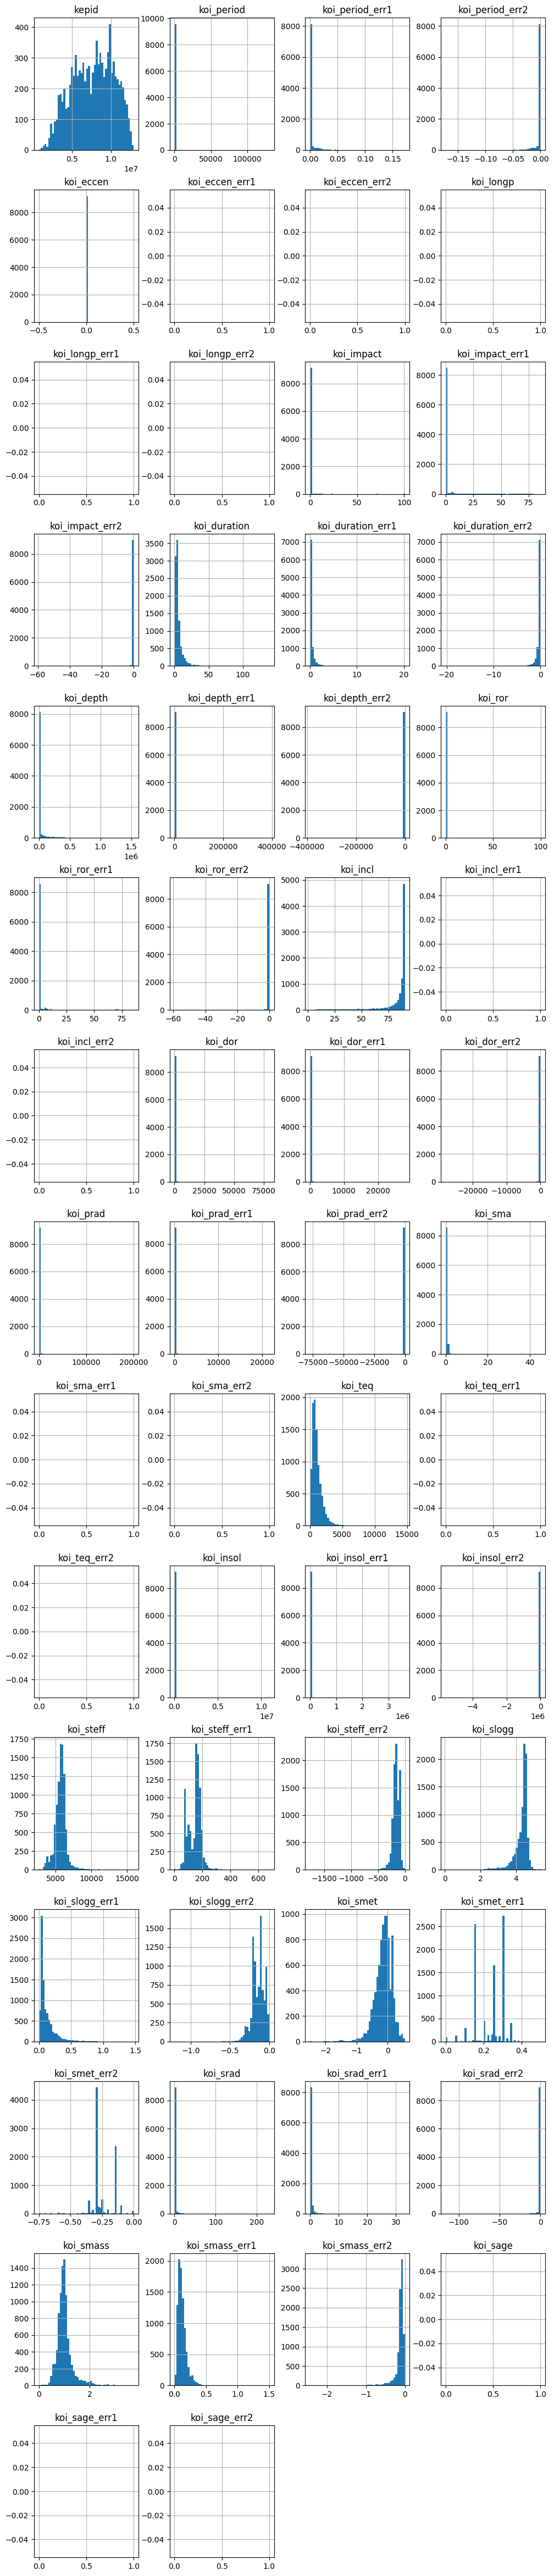

In [10]:
import matplotlib.pyplot as plt 

koi1.hist(bins=50, layout=(15, 4), figsize=(12, 60))
plt.show()

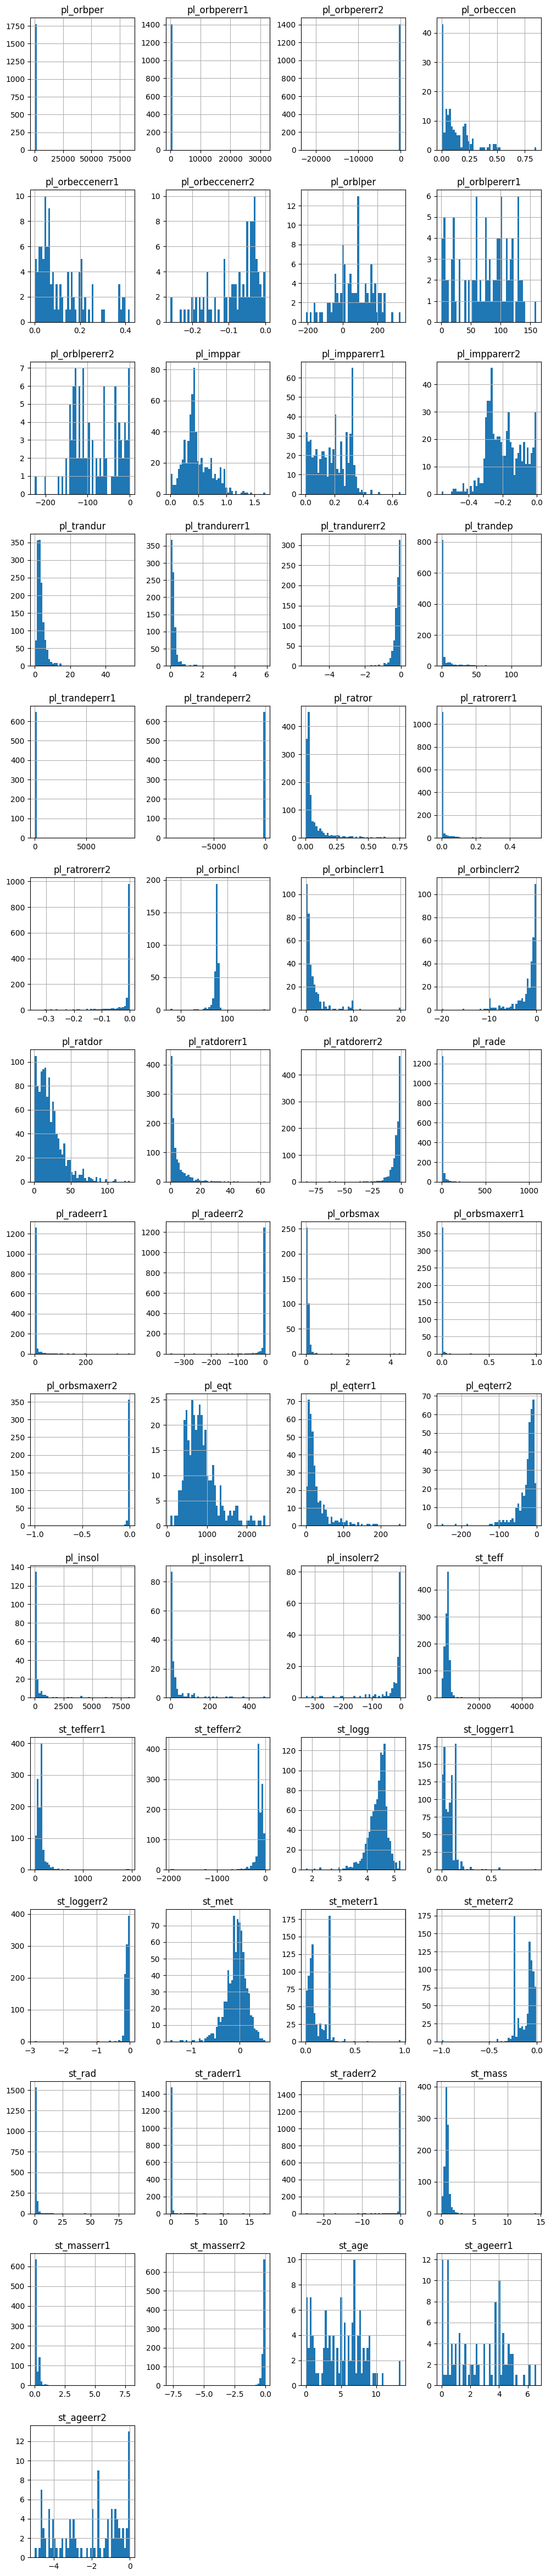

In [11]:
import matplotlib.pyplot as plt 

k2p1.hist(bins=50, layout=(15, 4), figsize=(12, 60))
plt.show()

### Division into train and test sets  
As only KOI dataset will be used for training, it will be split into a training (80% of the data) and test part (20%). 

In [12]:
from sklearn.model_selection import train_test_split 

train_set_koi, test_set_koi = train_test_split(koi1, test_size=0.2, stratify=koi1["koi_disposition"], random_state=42)
train_set_koi.to_csv("datasets/train_set_koi.csv", index=False)
test_set_koi.to_csv("datasets/test_set_koi.csv", index=False)